In [9]:
#%pip install numpy pandas scikit-learn matplotlib seaborn xgboost
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [10]:
# ============================================
# 1. โหลดข้อมูลและเลือก 5 ฟีเจอร์ที่ดีที่สุด
# ============================================
# โหลดข้อมูลที่ผ่านการ Clean และ Scaling มาแล้ว
df = pd.read_csv('pokemon_cleaned_for_selection.csv')

selected_features = ['hp', 'defense', 'height', 'speed', 'special_defense']

X_optimal = df[selected_features]
y = df['is_legendary']



In [ ]:
# ============================================
# 2. แบ่งข้อมูล (Train / Test Split) แบบ 80/20
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X_optimal, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ แบ่งข้อมูลสำเร็จ! Train: {X_train.shape[0]} ตัว | Test: {X_test.shape[0]} ตัว\n")

# ฟังก์ชันสำหรับประเมินผลและแสดงค่า (เพื่อลดการเขียนโค้ดซ้ำ)
def evaluate_model(model_name, y_true, y_pred):
    print(f"📊 ผลการประเมิน {model_name} (Evaluation Set):")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("-" * 40)

# ============================================
# ปรับสเกลข้อมูล (Standardization)
# ============================================
scaler = StandardScaler()

# ให้ scaler เรียนรู้และปรับสเกลจาก X_train เท่านั้น ป้องกันข้อมูล Test รั่วไหล
X_train_scaled = scaler.fit_transform(X_train)

# นำรูปแบบสเกลนั้นไปใช้กับ X_test ด้วย
X_test_scaled = scaler.transform(X_test)

✅ แบ่งข้อมูลสำเร็จ! Train: 200 ตัว | Test: 50 ตัว



In [12]:
# ============================================
# 3. Model 1: K-Nearest Neighbors (KNN)
# ============================================
print("กำลังเทรนโมเดล KNN...")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1')
grid_knn.fit(X_train_scaled, y_train)

print(f"🌟 Best Params (KNN): {grid_knn.best_params_}")
y_pred_knn = grid_knn.best_estimator_.predict(X_test_scaled)
evaluate_model("KNN", y_test, y_pred_knn)

กำลังเทรนโมเดล KNN...
🌟 Best Params (KNN): {'n_neighbors': 3, 'weights': 'uniform'}
📊 ผลการประเมิน KNN (Evaluation Set):
Accuracy:  0.9600
Precision: 0.5000
Recall:    0.5000
F1-Score:  0.5000
----------------------------------------


In [13]:
# ============================================
# 4. Model 2: XGBoost
# ============================================
print("กำลังเทรนโมเดล XGBoost...")
param_grid_xgb = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), param_grid_xgb, cv=5, scoring='f1')
grid_xgb.fit(X_train_scaled, y_train)

print(f"🌟 Best Params (XGBoost): {grid_xgb.best_params_}")
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test_scaled)
evaluate_model("XGBoost", y_test, y_pred_xgb)

กำลังเทรนโมเดล XGBoost...
🌟 Best Params (XGBoost): {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
📊 ผลการประเมิน XGBoost (Evaluation Set):
Accuracy:  0.9800
Precision: 1.0000
Recall:    0.5000
F1-Score:  0.6667
----------------------------------------


In [14]:
# ============================================
# 5. Model 3: Neural Network (MLPClassifier)
# ============================================
print("กำลังเทรนโมเดล Neural Network...")
param_grid_nn = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01]
}
# ปรับ max_iter เป็น 1000 ให้มันมีเวลาเรียนรู้มากขึ้น
grid_nn = GridSearchCV(MLPClassifier(max_iter=1000, random_state=42), param_grid_nn, cv=5, scoring='f1')

# เปลี่ยนเป็น X_train_scaled
grid_nn.fit(X_train_scaled, y_train)

print(f"🌟 Best Params (Neural Network): {grid_nn.best_params_}")

# เปลี่ยนเป็น X_test_scaled
y_pred_nn = grid_nn.best_estimator_.predict(X_test_scaled)
evaluate_model("Neural Network", y_test, y_pred_nn)

กำลังเทรนโมเดล Neural Network...
🌟 Best Params (Neural Network): {'activation': 'tanh', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
📊 ผลการประเมิน Neural Network (Evaluation Set):
Accuracy:  0.9800
Precision: 1.0000
Recall:    0.5000
F1-Score:  0.6667
----------------------------------------


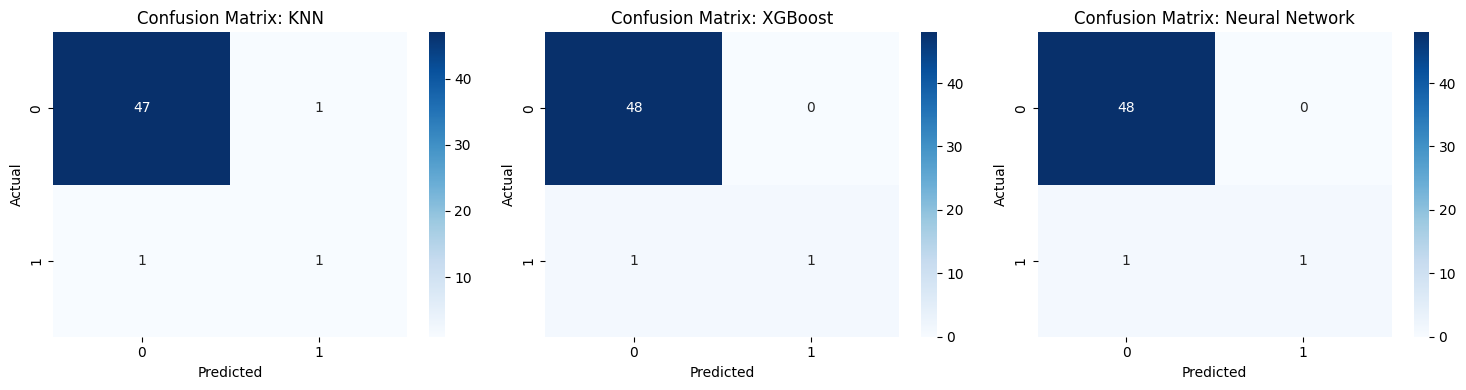

In [15]:
# ============================================
# 6. วาด Confusion Matrix เปรียบเทียบทั้ง 3 โมเดล
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_preds = [("KNN", y_pred_knn), ("XGBoost", y_pred_xgb), ("Neural Network", y_pred_nn)]

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix: {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()